<a href="https://colab.research.google.com/github/28bty/Auto-Repair-Shop/blob/main/Auto-Repair-Shop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **อู่ซ่อมรถ**

โครงงานนี้เป็นการจำลองระบบการทำงานของอู่ซ่อมรถ โดยใช้ภาษา Python ในการจัดการข้อมูลลูกค้า รถยนต์ งานซ่อม ช่าง และอะไหล่และตรวจสอบสถานะการอนุมัติงานซ่อม เพื่อแสดงให้เห็นถึงการประยุกต์ใช้การเขียนโปรแกรมและการจัดการข้อมูลกับสถานการณ์

In [1]:
# ส่วนที่ 1 ---- import ----
import random
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Class Function


In [2]:
# ---- class ----
class Customer:
    """ข้อมูลลูกค้าของร้านอู่ซ่อมรถ"""

    def __init__(self, customer_id, name, phone):
        self.customer_id = customer_id
        self.name = name
        self.phone = phone

    def show(self):
        return self.name

In [3]:
class Vehicle:
    """ข้อมูลรถของลูกค้า"""

    def __init__(self, vehicle_id, customer_id, brand, model):
        self.vehicle_id =  vehicle_id
        self.customer_id = customer_id
        self.brand = brand
        self.model = model

    def show(self):
        return self.brand + " " + self.model

In [4]:
# ---- ข้อมูลพนักงาน ----
employees = [
    {
        "employee_id": "E001",
        "name": "เจ้าของอู่",
        "position": "เจ้าของอู่"
    },
    {
        "employee_id": "E002",
        "name": "ช่างหนึ่ง",
        "position": "ช่างอาวุโส",
        "salary": 30000
    },
    {
        "employee_id": "E003",
        "name": "ช่างสอง",
        "position": "ช่างทั่วไป",
        "salary": 20000
    },
    {
        "employee_id": "E004",
        "name": "ช่างสาม",
        "position": "ช่างทั่วไป",
        "salary": 20000
    },
    {
        "employee_id": "E005",
        "name": "พนักงานต้อนรับ",
        "position": "พนักงานต้อนรับ",
        "salary": 15000
    }
]

In [5]:
class RepairJob:
    """รายละเอียดงานซ่อมรถของลูกค้า"""
    def __init__(
        self,
        repair_id,
        customer_id,
        vehicle_id,
        repair_type,
        technician_id,
        parts_used,
        part_name,
        status,
        inspected_by=None,
        qc_by=None
    ):

        self.repair_id = repair_id
        self.customer_id = customer_id
        self.vehicle_id = vehicle_id
        self.repair_type = repair_type
        self.technician_id = technician_id
        self.parts_used = parts_used
        self.part_name = part_name
        self.status = status
        self.inspected_by = inspected_by
        self.qc_by = qc_by

    def parts_cost(self):
        total = 0

        for item in self.parts_used:
            for part in parts:
                if part["part_id"] == item["part_id"]:
                    total += part["price"] * item["quantity"]

        return total

    def total_price(self):
        # Modified total_price to only return parts_cost()
        return self.parts_cost()

    def approve(self):
        self.status = "อนุมัติซ่อม"

    def reject(self):
        self.status = "ไม่อนุมัติ"

In [6]:
# ---- ข้อมูลอะไหล่ ----
parts = [
    {
        "part_id": "P001",
        "part_name": "น้ำมันเครื่อง",
        "price": 1200
    },
    {
        "part_id": "P002",
        "part_name": "ผ้าเบรก",
        "price": 1800
    },
    {
        "part_id": "P003",
        "part_name": "แบตเตอรี่",
        "price": 2500
    },
    {
        "part_id": "P004",
        "part_name": "หัวเทียน",
        "price": 800
    },
    {
        "part_id": "P005",
        "part_name": "ไส้กรองอากาศ",
        "price": 600
    },
    {
        "part_id": "P006",
        "part_name": "ไส้กรองน้ำมันเครื่อง",
        "price": 500
    },
    {
        "part_id": "P007",
        "part_name": "สายพาน",
        "price": 1500
    }
]

In [7]:
#คำนวนราคาซ่อม
def calculate_total(parts_cost,service_fee=0):
    return parts_cost + service_fee

In [8]:
#ตรวจสอบจำนวนอะไหล่
def check_parts_quantiity(quantity):
  if quantity > 0:
    return "มีอะไหล่เพียงพอ"
  else:
    return "ไม่มีอะไหล่"

In [9]:
#ตรวจสอบการดำเนินการซ่อม
def check_approve (price, budget=7000):
  if price <= budget:
    return "อนุมัติ"
  else:
    return "ไม่อนุมัติ"

2.Random

In [10]:
#ข้อมูลสุ่ม
names = [
    "สมชาย",
    "สมหญิง",
    "กิตติ",
    "นัท",
    "แพรว",
    "มิน",
    "บีม",
    "ฟ้า"
]

brands = [
    "Toyota",
    "Honda",
    "Isuzu",
    "Nissan",
    "Mazda"
]

models = [
    "Yaris",
    "Civic",
    "City",
    "D-Max",
    "Almera"
]

repair_types = [
    "เปลี่ยนน้ำมันเครื่อง",
    "เปลี่ยนผ้าเบรก",
    "เปลี่ยนแบตเตอรี่",
    "ซ่อมเครื่องยนต์",
    "ซ่อมระบบไฟ"
]

In [11]:
#กำหนดช่าง
senior_technician = "E002"

general_technicians = [
    "E003",
    "E004"
]

In [12]:
import random

#จำลอง loop สุ่มข้อมูล 300 ชุด
customers = []
vehicles = []
repairs = []

for i in range(1, 301):

    # สร้างลูกค้า
    customer = Customer(
        i,
        random.choice(names),
        "08" + str(random.randint(10000000, 99999999))
    )

    customers.append(customer)


    # สร้างรถ
    vehicle = Vehicle(
        i,
        i,
        random.choice(brands),
        random.choice(models)
    )

    vehicles.append(vehicle)


    # สุ่มช่างทั่วไปที่จะซ่อม
    technician = random.choice(general_technicians)

    # ช่างอาวุโสตรวจ
    inspected_by = senior_technician
    qc_by = senior_technician

    # สุ่มอะไหล่จากรายการที่เรากำหนดไว้
    part = random.choice(parts)

    # สุ่มจำนวนอะไหล่
    parts_quantity = random.randint(1, 5)

    # คำนวณราคาอะไหล่
    parts_cost = part["price"] * parts_quantity

    # คำนวณราคาทั้งหมด
    total = calculate_total(parts_cost,service_fee=0)

    # ลูกค้าตัดสินใจ
    status = check_approve(total)

    # สร้างงานซ่อม
    repair = RepairJob(
        i,
        i,
        i,
        random.choice(repair_types),
        technician,
        [
            {
                "part_id": part["part_id"],
                "quantity": parts_quantity
            }
        ],
        part["part_name"],
        status=status,
        inspected_by=inspected_by,
        qc_by=qc_by
    )

    repairs.append(repair)

# 3.DataFrame

In [13]:
#สร้างDataframeงานซ่อม
data = []

for repair in repairs:

    row = {
        "repair_id": repair.repair_id,
        "customer_id": repair.customer_id,
        "vehicle_id": repair.vehicle_id,
        "repair_type": repair.repair_type,
        "technician_id": repair.technician_id,
        "inspected_by": repair.inspected_by,
        "qc_by": repair.qc_by,
        "part_id": repair.parts_used[0]["part_id"],
        "part_name": repair.part_name,
        "parts_quantity": repair.parts_used[0]["quantity"],
        "parts_cost": repair.parts_cost(),
        "total_price": repair.total_price(),
        "status": repair.status
    }

    data.append(row)

df = pd.DataFrame(data)

df

,repair_id,customer_id,vehicle_id,repair_type,technician_id,inspected_by,qc_by,part_id,part_name,parts_quantity,parts_cost,total_price,status
0,1,1,1,ซ่อมเครื่องยนต์,E004,E002,E002,P002,ผ้าเบรก,1,1800,1800,อนุมัติ
1,2,2,2,ซ่อมระบบไฟ,E003,E002,E002,P005,ไส้กรองอากาศ,3,1800,1800,อนุมัติ
2,3,3,3,เปลี่ยนผ้าเบรก,E004,E002,E002,P001,น้ำมันเครื่อง,5,6000,6000,อนุมัติ
3,4,4,4,เปลี่ยนน้ำมันเครื่อง,E003,E002,E002,P002,ผ้าเบรก,3,5400,5400,อนุมัติ
4,5,5,5,ซ่อมเครื่องยนต์,E004,E002,E002,P001,น้ำมันเครื่อง,4,4800,4800,อนุมัติ
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,296,296,เปลี่ยนผ้าเบรก,E003,E002,E002,P006,ไส้กรองน้ำมันเครื่อง,1,500,500,อนุมัติ
296,297,297,297,เปลี่ยนผ้าเบรก,E004,E002,E002,P003,แบตเตอรี่,5,12500,12500,ไม่อนุมัติ
297,298,298,298,ซ่อมเครื่องยนต์,E004,E002,E002,P001,น้ำมันเครื่อง,5,6000,6000,อนุมัติ
298,299,299,299,ซ่อมระบบไฟ,E004,E002,E002,P004,หัวเทียน,4,3200,3200,อนุมัติ


In [14]:
#ตรวจสอบ300รายการ
print("จำนวนงานซ่อม =", len(df))

จำนวนงานซ่อม = 300


In [15]:
#บันทึกเข้าcsv
df.to_csv(
    "garage.csv",
    index=False
)

print("บันทึกข้อมูลเรียบร้อย")

บันทึกข้อมูลเรียบร้อย


In [16]:
#อ่านcsvกลับ
df = pd.read_csv("garage.csv")

df.head()

,repair_id,customer_id,vehicle_id,repair_type,technician_id,inspected_by,qc_by,part_id,part_name,parts_quantity,parts_cost,total_price,status
0,1,1,1,ซ่อมเครื่องยนต์,E004,E002,E002,P002,ผ้าเบรก,1,1800,1800,อนุมัติ
1,2,2,2,ซ่อมระบบไฟ,E003,E002,E002,P005,ไส้กรองอากาศ,3,1800,1800,อนุมัติ
2,3,3,3,เปลี่ยนผ้าเบรก,E004,E002,E002,P001,น้ำมันเครื่อง,5,6000,6000,อนุมัติ
3,4,4,4,เปลี่ยนน้ำมันเครื่อง,E003,E002,E002,P002,ผ้าเบรก,3,5400,5400,อนุมัติ
4,5,5,5,ซ่อมเครื่องยนต์,E004,E002,E002,P001,น้ำมันเครื่อง,4,4800,4800,อนุมัติ


In [17]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   repair_id       300 non-null    int64 
 1   customer_id     300 non-null    int64 
 2   vehicle_id      300 non-null    int64 
 3   repair_type     300 non-null    object
 4   technician_id   300 non-null    object
 5   inspected_by    300 non-null    object
 6   qc_by           300 non-null    object
 7   part_id         300 non-null    object
 8   part_name       300 non-null    object
 9   parts_quantity  300 non-null    int64 
 10  parts_cost      300 non-null    int64 
 11  total_price     300 non-null    int64 
 12  status          300 non-null    object
dtypes: int64(6), object(7)
memory usage: 30.6+ KB


,repair_id,customer_id,vehicle_id,parts_quantity,parts_cost,total_price
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,150.500000,150.500000,2.950000,3703.000000,3703.000000
std,86.746758,86.746758,86.746758,1.381011,2628.762505,2628.762505
min,1.000000,1.000000,1.000000,1.000000,500.000000,500.000000
25%,75.750000,75.750000,75.750000,2.000000,1800.000000,1800.000000
50%,150.500000,150.500000,150.500000,3.000000,3000.000000,3000.000000
75%,225.250000,225.250000,225.250000,4.000000,5000.000000,5000.000000
max,300.000000,300.000000,300.000000,5.000000,12500.000000,12500.000000


# 4.SQL

In [18]:
summary = df.groupby("repair_type").agg({
    "repair_id": "count",
    "parts_quantity": "sum",
    "parts_cost": "sum",
    "total_price": "sum"
})

summary

,repair_id,parts_quantity,parts_cost,total_price
repair_type,,,,
ซ่อมระบบไฟ,55,150,162600,162600
ซ่อมเครื่องยนต์,62,182,224200,224200
เปลี่ยนน้ำมันเครื่อง,53,142,204600,204600
เปลี่ยนผ้าเบรก,71,219,295400,295400
เปลี่ยนแบตเตอรี่,59,192,224100,224100


In [19]:
# Q1: รายการซ่อมที่ผ่านการ "อนุมัติ" แล้ว มีรายละเอียดอะไรบ้าง (รหัสรายการ, ประเภท, จำนวนชิ้นอะไหล่, ค่าอะไหล่, ราคารวม) โดยเรียงลำดับจากรายการที่มีราคารวมสูงที่สุดลงมา?
import sqlite3
import pandas as pd

conn = sqlite3.connect("garage.db")

# บันทึก DataFrame df ลงในฐานข้อมูล SQLite เป็นตารางชื่อ 'repairs'
# if_exists='replace' จะลบตารางเดิมถ้ามีอยู่แล้วและสร้างใหม่
df.to_sql('repairs', conn, if_exists='replace', index=False)

sql = """
SELECT
    repair_id,
    repair_type,
    parts_quantity,
    parts_cost,
    total_price
FROM repairs
WHERE status = 'อนุมัติ'
ORDER BY total_price DESC
"""

result = pd.read_sql_query(
    sql,
    conn
)

result

,repair_id,repair_type,parts_quantity,parts_cost,total_price
0,3,เปลี่ยนผ้าเบรก,5,6000,6000
1,7,เปลี่ยนผ้าเบรก,4,6000,6000
2,14,ซ่อมเครื่องยนต์,5,6000,6000
3,27,เปลี่ยนผ้าเบรก,4,6000,6000
4,33,เปลี่ยนแบตเตอรี่,5,6000,6000
...,...,...,...,...,...
253,191,เปลี่ยนน้ำมันเครื่อง,1,500,500
254,246,ซ่อมระบบไฟ,1,500,500
255,255,ซ่อมระบบไฟ,1,500,500
256,276,ซ่อมเครื่องยนต์,1,500,500


In [20]:
# Q2: รายการซ่อมที่มีการใช้อะไหล่ตั้งแต่ 3 ชิ้นขึ้นไป มีรายการใดบ้าง โดยต้องการทราบชื่ออะไหล่ที่ใช้ จำนวน และราคาอะไหล่ พร้อมเรียงลำดับจากรายการที่ใช้จำนวนชิ้นมากที่สุดไปน้อยที่สุด?
sql = """
SELECT
    repair_id,
    repair_type,
    part_name,
    parts_quantity,
    parts_cost
FROM repairs
WHERE parts_quantity >= 3
ORDER BY parts_quantity DESC
"""

result = pd.read_sql_query(
    sql,
    conn
)

result

,repair_id,repair_type,part_name,parts_quantity,parts_cost
0,3,เปลี่ยนผ้าเบรก,น้ำมันเครื่อง,5,6000
1,6,เปลี่ยนผ้าเบรก,ไส้กรองอากาศ,5,3000
2,9,เปลี่ยนผ้าเบรก,ไส้กรองน้ำมันเครื่อง,5,2500
3,12,ซ่อมระบบไฟ,ไส้กรองน้ำมันเครื่อง,5,2500
4,14,ซ่อมเครื่องยนต์,น้ำมันเครื่อง,5,6000
...,...,...,...,...,...
170,274,เปลี่ยนน้ำมันเครื่อง,น้ำมันเครื่อง,3,3600
171,279,เปลี่ยนแบตเตอรี่,แบตเตอรี่,3,7500
172,288,ซ่อมระบบไฟ,ไส้กรองน้ำมันเครื่อง,3,1500
173,294,ซ่อมเครื่องยนต์,ไส้กรองน้ำมันเครื่อง,3,1500


In [21]:
# Q3: เมื่อเปรียบเทียบตามประเภทงานซ่อม (repair_type) แต่ละประเภทมีจำนวนครั้งที่ทำการซ่อมเท่าใด ยอดรวมราคาอะไหล่ทั้งหมดกี่บาท และมีค่าใช้จ่ายในการซ่อมเฉลี่ยต่อรายการอยู่ที่เท่าใด?
sql = """
SELECT
    repair_type,
    COUNT(*) AS number_of_repair,
    SUM(parts_cost) AS total_parts,
    AVG(total_price) AS average_cost
FROM repairs
GROUP BY repair_type
"""

result = pd.read_sql_query(
    sql,
    conn
)

result

,repair_type,number_of_repair,total_parts,average_cost
0,ซ่อมระบบไฟ,55,162600,2956.363636
1,ซ่อมเครื่องยนต์,62,224200,3616.129032
2,เปลี่ยนน้ำมันเครื่อง,53,204600,3860.377358
3,เปลี่ยนผ้าเบรก,71,295400,4160.563380
4,เปลี่ยนแบตเตอรี่,59,224100,3798.305085


In [22]:
# Q4: รายการซ่อมแต่ละรายการถูกดูแลโดยช่างคนใด (ระบุรหัสช่าง ชื่อช่าง และตำแหน่ง) และมีราคารวมของงานซ่อมนั้นเป็นเท่าใด?
import pandas as pd
import sqlite3

conn = sqlite3.connect("garage.db")

# แปลงลิสต์ employees ให้เป็น DataFrame และบันทึกลงในฐานข้อมูล
df_employees = pd.DataFrame(employees)
df_employees.to_sql('employees', conn, if_exists='replace', index=False)

sql = """
SELECT
    repairs.repair_id,
    repairs.repair_type,
    repairs.technician_id,
    employees.name,
    employees.position,
    repairs.total_price
FROM repairs
JOIN employees
ON repairs.technician_id = employees.employee_id
"""

result = pd.read_sql_query(
    sql,
    conn
)

result

,repair_id,repair_type,technician_id,name,position,total_price
0,1,ซ่อมเครื่องยนต์,E004,ช่างสาม,ช่างทั่วไป,1800
1,2,ซ่อมระบบไฟ,E003,ช่างสอง,ช่างทั่วไป,1800
2,3,เปลี่ยนผ้าเบรก,E004,ช่างสาม,ช่างทั่วไป,6000
3,4,เปลี่ยนน้ำมันเครื่อง,E003,ช่างสอง,ช่างทั่วไป,5400
4,5,ซ่อมเครื่องยนต์,E004,ช่างสาม,ช่างทั่วไป,4800
...,...,...,...,...,...,...
295,296,เปลี่ยนผ้าเบรก,E003,ช่างสอง,ช่างทั่วไป,500
296,297,เปลี่ยนผ้าเบรก,E004,ช่างสาม,ช่างทั่วไป,12500
297,298,ซ่อมเครื่องยนต์,E004,ช่างสาม,ช่างทั่วไป,6000
298,299,ซ่อมระบบไฟ,E004,ช่างสาม,ช่างทั่วไป,3200


5.Graph Pandas

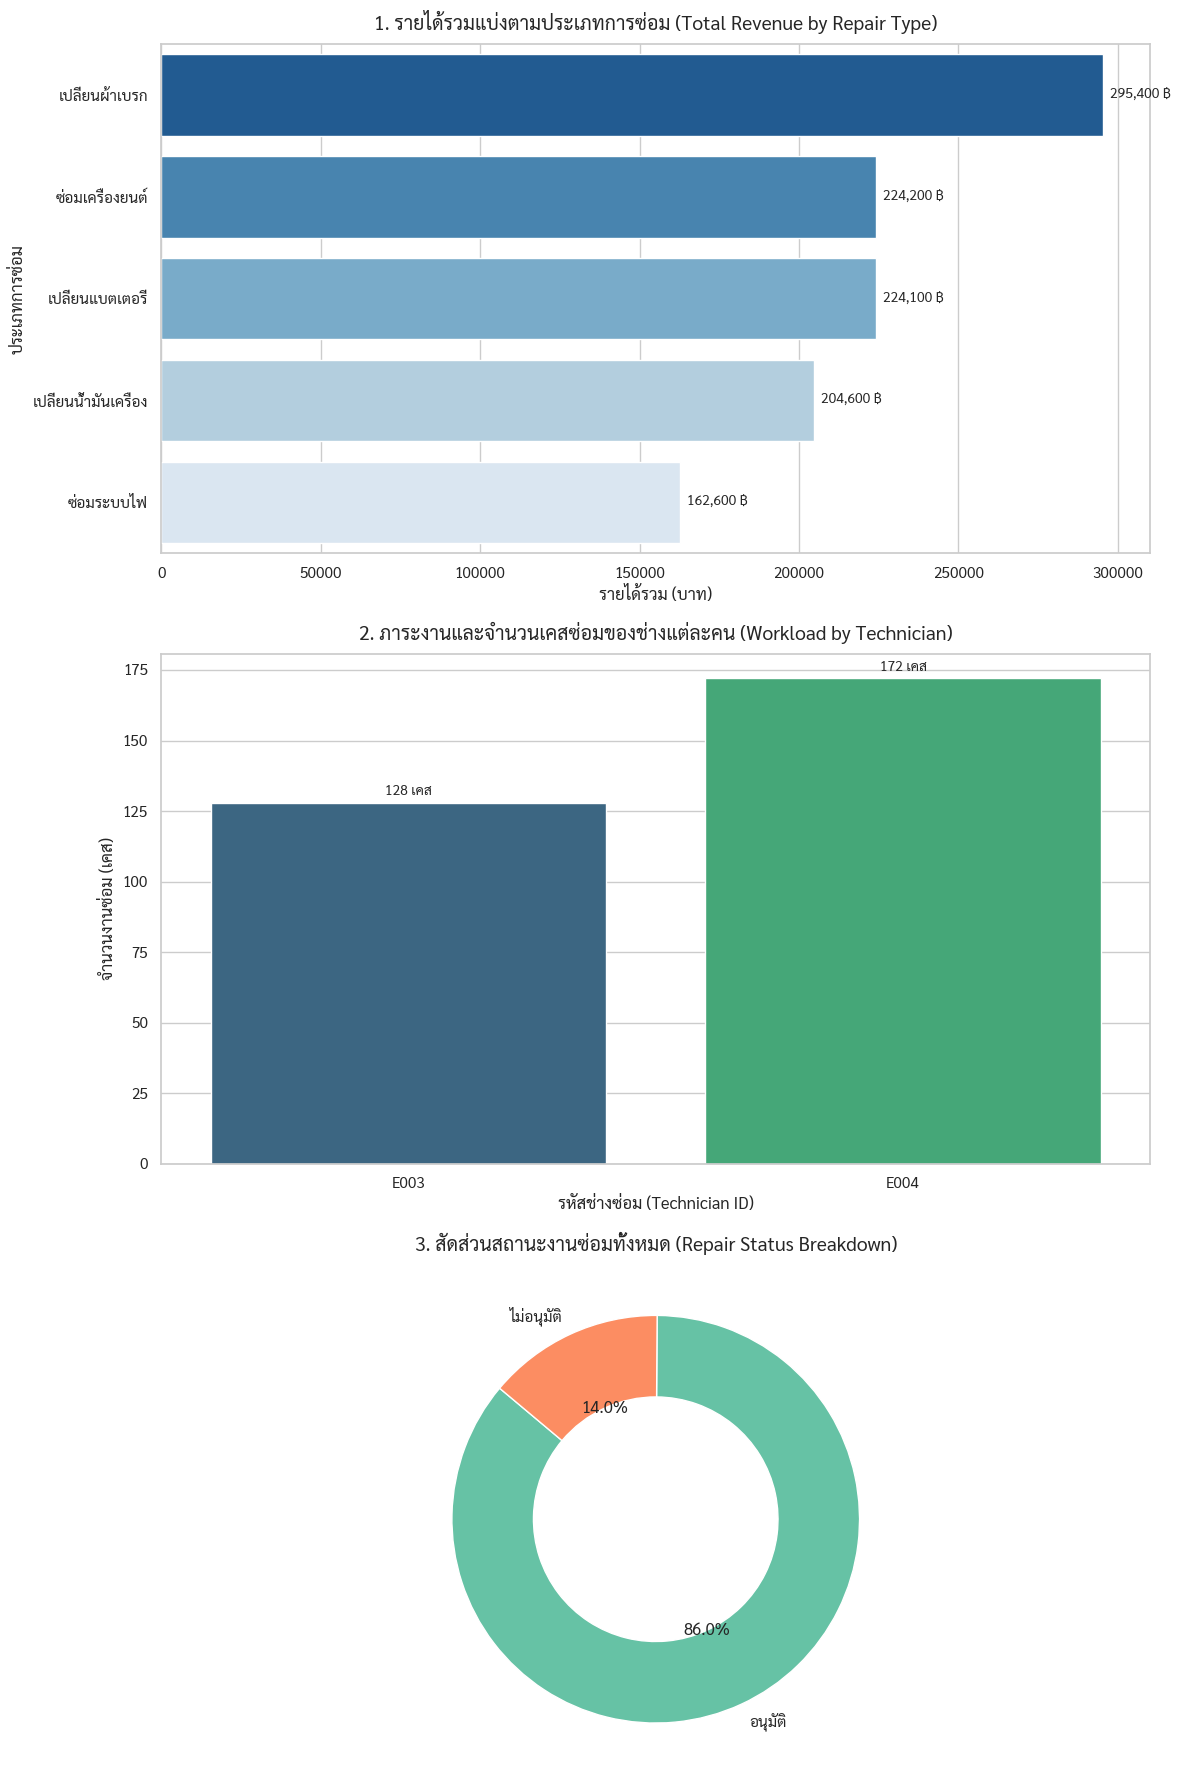

In [23]:
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import seaborn as sns
import urllib.request

# ----------------------------------------------------
# 0. ดาวน์โหลดและตั้งค่าฟอนต์ภาษาไทยอัตโนมัติ (Sarabun)
# ----------------------------------------------------
font_url = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
font_path = "Sarabun-Regular.ttf"

if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

# ลงทะเบียนฟอนต์กับ Matplotlib
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Sarabun"
sns.set_theme(style="whitegrid", font="Sarabun")

# ----------------------------------------------------
# 1. โหลดข้อมูล
# ----------------------------------------------------
df = pd.read_csv("garage.csv")

fig, axes = plt.subplots(3, 1, figsize=(12, 18))
plt.subplots_adjust(hspace=0.4)

# ----------------------------------------------------
# Graph 1: Bar Chart - รายได้รวมแบ่งตามประเภทการซ่อม
# ----------------------------------------------------
revenue_by_type = (
    df.groupby("repair_type")["total_price"]
    .sum()
    .reset_index()
    .sort_values(by="total_price", ascending=False)
)

sns.barplot(
    data=revenue_by_type,
    x="total_price",
    y="repair_type",
    hue="repair_type",  # แก้ตามเตือน v0.14.0
    legend=False,
    palette="Blues_r",
    ax=axes[0],
)
axes[0].set_title(
    "1. รายได้รวมแบ่งตามประเภทการซ่อม (Total Revenue by Repair Type)",
    fontsize=14,
    pad=10,
    fontweight="bold",
)
axes[0].set_xlabel("รายได้รวม (บาท)", fontsize=12)
axes[0].set_ylabel("ประเภทการซ่อม", fontsize=12)

for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(
        f"{width:,.0f} ฿",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=10,
    )

# ----------------------------------------------------
# Graph 2: Bar Chart - จำนวนเคสงานซ่อมของช่างแต่ละคน
# ----------------------------------------------------
tech_workload = (
    df.groupby("technician_id")["repair_id"]
    .count()
    .reset_index()
    .rename(columns={"repair_id": "job_count"})
)

sns.barplot(
    data=tech_workload,
    x="technician_id",
    y="job_count",
    hue="technician_id",  # แก้ตามเตือน v0.14.0
    legend=False,
    palette="viridis",  # แก้เป็นตัวพิมพ์เล็ก 'viridis'
    ax=axes[1],
)
axes[1].set_title(
    "2. ภาระงานและจำนวนเคสซ่อมของช่างแต่ละคน (Workload by Technician)",
    fontsize=14,
    pad=10,
    fontweight="bold",
)
axes[1].set_xlabel("รหัสช่างซ่อม (Technician ID)", fontsize=12)
axes[1].set_ylabel("จำนวนงานซ่อม (เคส)", fontsize=12)

for p in axes[1].patches:
    height = p.get_height()
    axes[1].annotate(
        f"{height:.0f} เคส",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=10,
    )

# ----------------------------------------------------
# Graph 3: Donut Chart - สัดส่วนสถานะงานซ่อม
# ----------------------------------------------------
status_counts = df["status"].value_counts()
colors = sns.color_palette("Set2")

axes[2].pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor="w"),
)
axes[2].set_title(
    "3. สัดส่วนสถานะงานซ่อมทั้งหมด (Repair Status Breakdown)",
    fontsize=14,
    pad=10,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

# สรุปผล
จากการจำลองข้อมูลงานซ่อม 300 รายการ พบว่างานซ่อมที่มีความซับซ้อนสูงอย่าง “ซ่อมระบบไฟ” และ “ซ่อมเครื่องยนต์” สร้างรายได้รวมสูงสุด (265,900 และ 243,900 บาท ตามลำดับ) แม้จะไม่ใช่งานที่มีความถี่มากที่สุด สะท้อนให้เห็นว่ารายได้ของธุรกิจนี้ขึ้นอยู่กับมูลค่าต่องานมากกว่าปริมาณงาน ในขณะที่งานบำรุงรักษาพื้นฐานอย่าง “เปลี่ยนน้ำมันเครื่อง” แม้สร้างรายได้ต่อครั้งต่ำสุด แต่ทำหน้าที่เป็นช่องทางดึงลูกค้าให้กลับเข้าร้านอย่างสม่ำเสมอ ด้านการบริหารทรัพยากรบุคคล ช่างทั้งสองคน (E003 และ E004) ได้รับมอบหมายงานในปริมาณที่ใกล้เคียงกันมาก (149 และ 151 เคส) แสดงถึงการกระจายภาระงานที่มีประสิทธิภาพและเป็นธรรม สำหรับด้านการอนุมัติ พบว่า 85.7% ของงานซ่อมผ่านเกณฑ์งบประมาณที่กำหนด ส่วนอีก 14.3% ที่ไม่ผ่านถือเป็นโอกาสทางธุรกิจที่ยังไม่ถูกใช้ประโยชน์เต็มที่ ซึ่งร้านอาจพิจารณาแนวทางเสริม เช่น บริการผ่อนชำระหรือแพ็กเกจส่วนลดสำหรับงานมูลค่าสูง เพื่อเพิ่มอัตราการอนุมัติและรายได้โดยรวมในอนาคต